# Plant Disease Detection using YOLOv8

# Download Dataset

In [ ]:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NaGZDBPtaV5Ak4QgG7sf")
project = rf.workspace("fyp-advun").project("crop-disease-2rilx")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to crop-disease-1 in yolov8:: 100%|██████████| 9614/9614 [00:01<00:00, 6779.31it/s]


# Merge Dataset

In [ ]:


import os, shutil

def merge_data(base_path, out_img, out_lbl):
    splits = ["train", "valid", "test"]

    os.makedirs(out_img, exist_ok=True)
    os.makedirs(out_lbl, exist_ok=True)

    for split in splits:
        img_dir = os.path.join(base_path, split, "images")
        lbl_dir = os.path.join(base_path, split, "labels")

        for img in os.listdir(img_dir):
            new_name = f"{split}_{img}"

            shutil.copy(os.path.join(img_dir, img),
                        os.path.join(out_img, new_name))

            label_name = os.path.splitext(img)[0] + ".txt"

            if os.path.exists(os.path.join(lbl_dir, label_name)):
                shutil.copy(os.path.join(lbl_dir, label_name),
                            os.path.join(out_lbl,
                            new_name.replace(".jpg", ".txt")))

In [ ]:
# Enable merging

merge_data(
    dataset.location,
    "/content/all_images",
    "/content/all_labels"
)

# Split 60/20/20

In [ ]:


import random

def split_dataset(images_path, labels_path, output_path):
    random.seed(42)

    images = [img for img in os.listdir(images_path)
              if img.endswith(('.jpg', '.png'))]

    random.shuffle(images)

    train_end = int(0.6 * len(images))
    val_end = int(0.8 * len(images))

    splits = {
        "train": images[:train_end],
        "valid": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split in splits:
        os.makedirs(f"{output_path}/{split}/images", exist_ok=True)
        os.makedirs(f"{output_path}/{split}/labels", exist_ok=True)

        for img in splits[split]:
            shutil.copy(os.path.join(images_path, img),
                        f"{output_path}/{split}/images/{img}")

            label = os.path.splitext(img)[0] + ".txt"

            if os.path.exists(os.path.join(labels_path, label)):
                shutil.copy(os.path.join(labels_path, label),
                            f"{output_path}/{split}/labels/{label}")

In [ ]:
# Enable splitting

split_dataset(
    "/content/all_images",
    "/content/all_labels",
    "/content/dataset_final"
)

In [ ]:
import os
from collections import Counter

def count_classes(labels_path):
    counter = Counter()

    for file in os.listdir(labels_path):
        if not file.endswith(".txt"):
            continue

        with open(os.path.join(labels_path, file)) as f:
            lines = f.readlines()

        for line in lines:
            class_id = int(line.split()[0])
            counter[class_id] += 1

    return counter


# enable on train set only
counts = count_classes("/content/dataset_final/train/labels")

print("Class Distribution:")
for k, v in counts.items():
    print(f"class {k}: {v}")

Class Distribution:
class 10: 124
class 13: 118
class 20: 125
class 8: 142
class 11: 150
class 22: 110
class 6: 98
class 4: 177
class 12: 298
class 16: 112
class 17: 114
class 2: 135
class 3: 155
class 19: 104
class 0: 446
class 7: 153
class 15: 123
class 21: 129
class 1: 137
class 14: 107
class 5: 124
class 9: 144
class 18: 302


# Checking of Data Leakage

In [ ]:
import os

train_files = set(os.listdir("/content/dataset_final/train/images"))
test_files = set(os.listdir("/content/dataset_final/test/images"))

common = train_files.intersection(test_files)

print("Common files:", len(common))

Common files: 0


In [ ]:
import os

images_path = "/content/dataset_final/train/images"
labels_path = "/content/dataset_final/train/labels"

missing_labels = []
missing_images = []

# check images -> labels
for img in os.listdir(images_path):
    label = os.path.splitext(img)[0] + ".txt"
    if not os.path.exists(os.path.join(labels_path, label)):
        missing_labels.append(img)

# check labels -> images
for lbl in os.listdir(labels_path):
    img = os.path.splitext(lbl)[0] + ".jpg"
    if not os.path.exists(os.path.join(images_path, img)):
        missing_images.append(lbl)

print("Images without labels:", len(missing_labels))
print("Labels without images:", len(missing_images))

Images without labels: 0
Labels without images: 0


In [ ]:
#  number of images before balance

import os

train_images = "/content/dataset_final/train/images"

print("Before balance:", len(os.listdir(train_images)))

Before balance: 2880


# Dataset Balancing

In [ ]:
#Balance Function

def duplicate_minority(images_path, labels_path, target_class=0, factor=2):
    images = os.listdir(images_path)

    for img in images:
        label_file = os.path.splitext(img)[0] + ".txt"
        label_path = os.path.join(labels_path, label_file)

        if not os.path.exists(label_path):
            continue

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:
            if int(line.split()[0]) == target_class:

                for i in range(factor):
                    new_name = f"dup_{i}_{img}"

                    shutil.copy(os.path.join(images_path, img),
                                os.path.join(images_path, new_name))

                    shutil.copy(label_path,
                                os.path.join(labels_path,
                                new_name.replace(".jpg",".txt")))

In [ ]:
##Class Balance Plan

balance_plan = {
    19:2, 15:2, 22:2, 13:2, 14:2, 21:2,
    10:2, 20:2, 6:2, 16:2, 17:2,
    5:2, 1:2, 11:2, 2:2, 9:2, 7:2, 8:2
}

In [ ]:
#Apply Balance (TRAIN ONLY)

for cls, factor in balance_plan.items():
    duplicate_minority(
        "/content/dataset_final/train/images",
        "/content/dataset_final/train/labels",
        target_class=cls,
        factor=factor
    )

print("Balance Done ")

Balance Done 


In [ ]:
# number of images after balance

import os

train_images = "/content/dataset_final/train/images"

print("After balance:", len(os.listdir(train_images)))

After balance: 7280


In [ ]:
from collections import Counter
import os

counter = Counter()

for file in os.listdir("/content/dataset_final/train/labels"):
    if file.endswith(".txt"):
        with open(os.path.join("/content/dataset_final/train/labels", file)) as f:
            for line in f:
                cls = int(line.split()[0])
                counter[cls] += 1

for k, v in sorted(counter.items()):
    print(f"class {k}: {v}")

class 0: 446
class 1: 411
class 2: 405
class 3: 155
class 4: 177
class 5: 372
class 6: 294
class 7: 459
class 8: 426
class 9: 432
class 10: 372
class 11: 450
class 12: 298
class 13: 354
class 14: 321
class 15: 369
class 16: 336
class 17: 342
class 18: 302
class 19: 312
class 20: 375
class 21: 387
class 22: 330


# Downloading ultralytics library

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00


In [ ]:
import yaml

with open(dataset.location + "/data.yaml") as f:
    original_yaml = yaml.safe_load(f)

print(original_yaml["names"])

['Chili___Anthracnose_fruit', 'Chili___Bacterial_leaf_spot', 'Chili___Healthy_fruit', 'Chili___Healthy_leaf', 'Chili___Mosaic_virus_leaf', 'Eggplant___Cercospora_leaf_spot', 'Eggplant___Colorado_potato_beetle', 'Eggplant___Fruit_rot', 'Eggplant___Healthy_fruit', 'Eggplant___Healthy_leaf', 'Potato___Alternaria_solani_leaf', 'Potato___Common_scab_fruit', 'Potato___Healthy_fruit', 'Potato___Healthy_leaf', 'Potato___Phytopthora_infestans_leaf', 'Tomato___Antrhacnose_fruit', 'Tomato___Bacterial_spot_leaf', 'Tomato___Early_blight_leaf', 'Tomato___Healthy_fruit', 'Tomato___Healthy_leaf', 'Tomato___Late_blight_leaf', 'Tomato___Leaf_mold', 'Tomato___Tomato_yellow_leaf_curl_virus']


In [ ]:
import yaml

data_yaml = {
    "path": "/content/dataset_final",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",

    "names": [
        'Chili___Anthracnose_fruit',
        'Chili___Bacterial_leaf_spot',
        'Chili___Healthy_fruit',
        'Chili___Healthy_leaf',
        'Chili___Mosaic_virus_leaf',
        'Eggplant___Cercospora_leaf_spot',
        'Eggplant___Colorado_potato_beetle',
        'Eggplant___Fruit_rot',
        'Eggplant___Healthy_fruit',
        'Eggplant___Healthy_leaf',
        'Potato___Alternaria_solani_leaf',
        'Potato___Common_scab_fruit',
        'Potato___Healthy_fruit',
        'Potato___Healthy_leaf',
        'Potato___Phytopthora_infestans_leaf',
        'Tomato___Antrhacnose_fruit',
        'Tomato___Bacterial_spot_leaf',
        'Tomato___Early_blight_leaf',
        'Tomato___Healthy_fruit',
        'Tomato___Healthy_leaf',
        'Tomato___Late_blight_leaf',
        'Tomato___Leaf_mold',
        'Tomato___Tomato_yellow_leaf_curl_virus'
    ]
}

with open("/content/dataset_final/data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml")

data.yaml


# Model Training

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/dataset_final/data.yaml",
    epochs=50,
    imgsz=320,
    batch=16,

    device=0,

    optimizer="AdamW",
    lr0=0.001,

    patience=10,

)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_final/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c9de7c24140>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.0420

# Model training on Augmented data

In [ ]:
from ultralytics import YOLO

# Augmentation Settings
aug_params = {
    "fliplr": 0.0,
    "flipud": 0.0,

    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,

    "degrees": 10,
    "scale": 0.5,
    "translate": 0.1,

    "mosaic": 1.0
}

model = YOLO("yolov8s.pt")

# experiment / training
results = model.train(
    data="/content/dataset_final/data.yaml",
    epochs=50,
    imgsz=320,
    batch=16,

    **aug_params,

    project="augmentation_experiments",
    name="exp_no_flip",
    save=True
)

print("Experiment finished")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_final/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_no_flip, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

#  Evaluation Metrics

In [ ]:
from ultralytics import YOLO

# load trained model
model = YOLO("/content/best (4).pt")

# validation
metrics = model.val()

print("===== METRICS =====")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

print("\n Confusion Matrix saved in runs folder")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,134,485 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 698.0±406.3 MB/s, size: 18.8 KB)
val: Scanning /content/dataset_final/valid/labels.cache... 960 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 960/960 366.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 8.6it/s 7.0s
                   all        960       1174      0.971      0.972      0.986      0.716
Chili___Anthracnose_fruit         36         92      0.977      0.919      0.987      0.554
Chili___Bacterial_leaf_spot         51         55      0.976      0.982      0.995      0.845
 Chili___Healthy_fruit         47         47      0.974          1      0.995      0.496
  Chili___Healthy_leaf         49         55      0.992          1      0.995      0.735
Chili___Mosaic_virus_leaf        

In [ ]:
!mkdir test_images

In [ ]:
!unzip "/content/test_img.zip"

Archive:  /content/test_img.zip
  inflating: test_img/WhatsApp Image 2026-05-02 at 5.19.24 PM (1).jpeg  
  inflating: test_img/WhatsApp Image 2026-05-02 at 5.19.24 PM.jpeg  
  inflating: test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM (1).jpeg  
  inflating: test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM (2).jpeg  
  inflating: test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM.jpeg  


# Testing the Model with External testing images


image 1/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.24 PM (1).jpeg: 320x256 1 Eggplant___Fruit_rot, 72.7ms
image 2/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.24 PM.jpeg: 224x320 4 Tomato___Healthy_fruits, 72.4ms
image 3/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM (1).jpeg: 224x320 3 Tomato___Healthy_fruits, 11.2ms
image 4/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM (2).jpeg: 320x320 1 Eggplant___Healthy_fruit, 10.8ms
image 5/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM.jpeg: 224x320 1 Potato___Common_scab_fruit, 12.0ms
Speed: 1.5ms preprocess, 35.8ms inference, 1.8ms postprocess per image at shape (1, 3, 224, 320)
Results saved to /content/runs/detect/predict


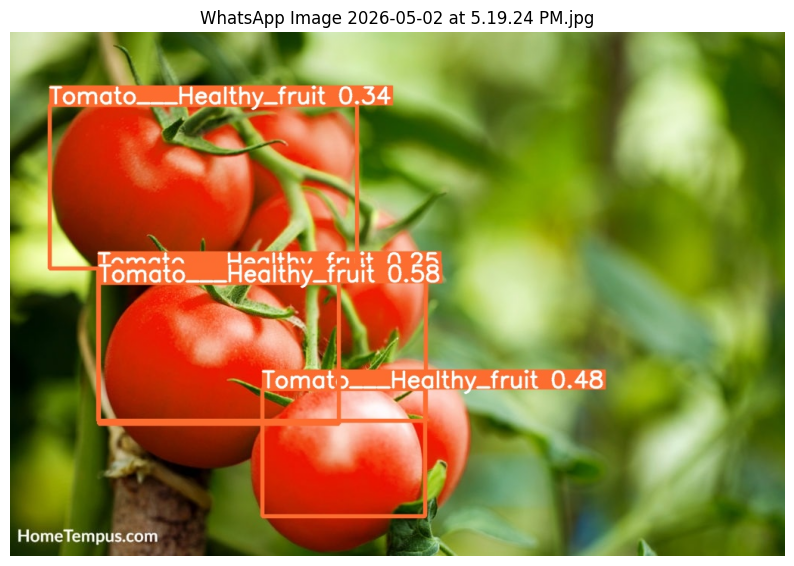

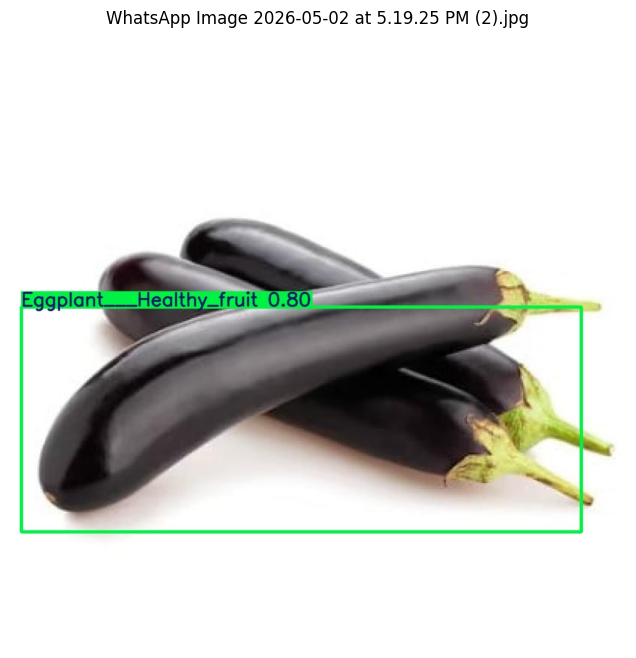

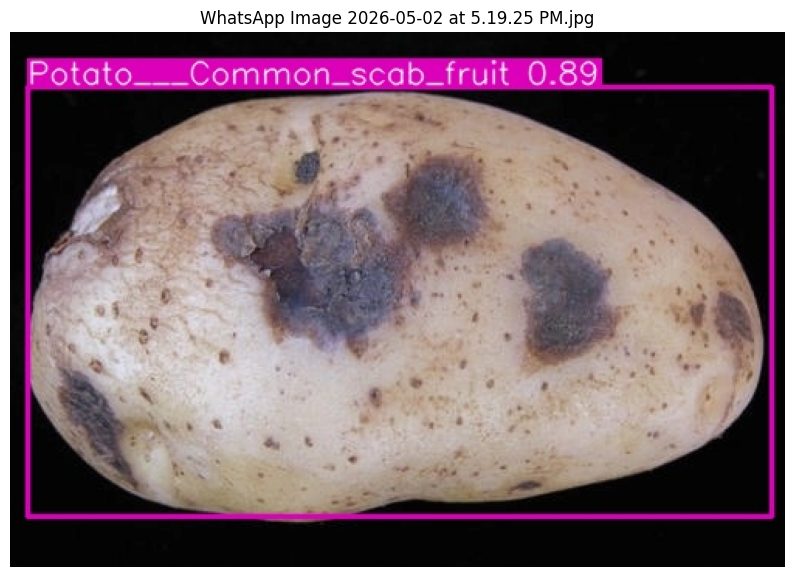

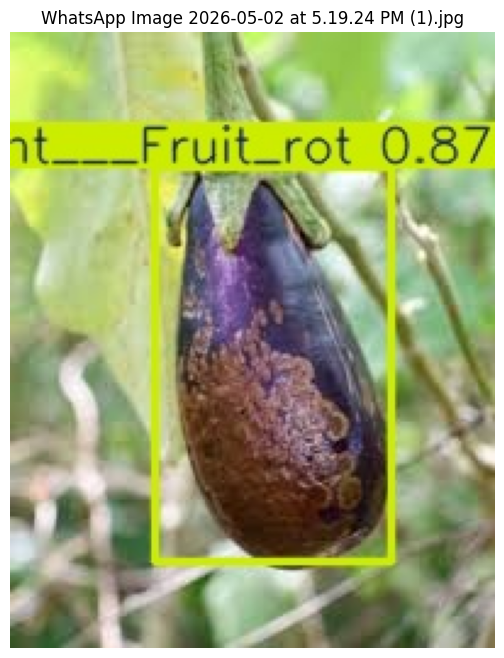

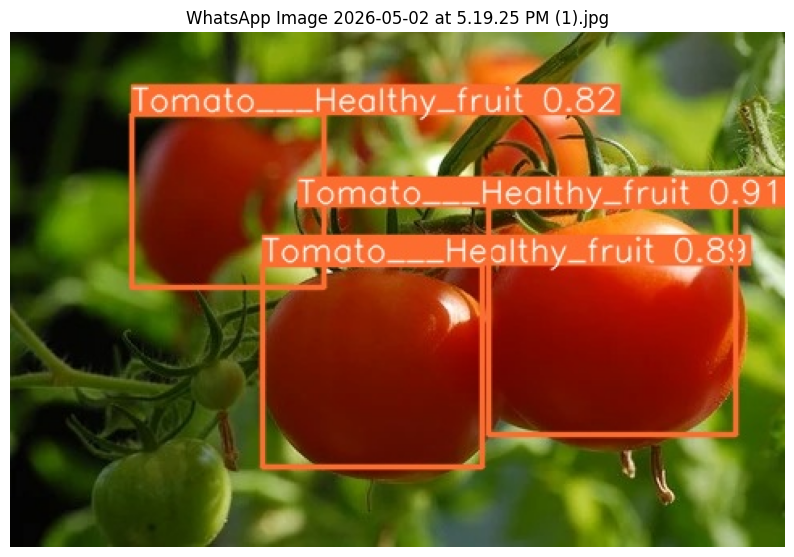

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 553.7±240.8 MB/s, size: 15.6 KB)
val: Scanning /content/dataset_final/valid/labels.cache... 960 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 960/960 251.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 8.0it/s 7.5s
                   all        960       1174      0.971      0.972      0.986      0.716
Chili___Anthracnose_fruit         36         92      0.977      0.919      0.987      0.554
Chili___Bacterial_leaf_spot         51         55      0.976      0.982      0.995      0.845
 Chili___Healthy_fruit         47         47      0.974          1      0.995      0.496
  Chili___Healthy_leaf         49         55      0.992          1      0.995      0.735
Chili___Mosaic_virus_leaf         52         52      0.995          1      0.995      0.734
Eggplant___Cercospora_l

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load model
model = YOLO("/content/best (4).pt")

# Predict on external test images
model.predict(
    source="/content/test_img",
    save=True,
    conf=0.25
)

# Show prediction results
predict_path = "/content/runs/detect/predict"

for img_name in os.listdir(predict_path):

    if img_name.endswith(('.jpg', '.png', '.jpeg')):

        img_path = os.path.join(predict_path, img_name)

        image = Image.open(img_path)

        plt.figure(figsize=(10,8))
        plt.imshow(image)
        plt.axis("off")
        plt.title(img_name)
        plt.show()

# Evaluation Metrics
results = model.val(data="/content/dataset_final/data.yaml")

print("\nEvaluation Metrics:\n")

print(f"Precision: {results.box.mp:.4f}")
print(f"Recall: {results.box.mr:.4f}")
print(f"mAP@0.5: {results.box.map50:.4f}")

# Testing the Model trained on augmented data with External testing images


image 1/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.24 PM (1).jpeg: 320x256 1 Eggplant___Fruit_rot, 8.2ms
image 2/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.24 PM.jpeg: 224x320 1 Tomato___Healthy_fruit, 8.4ms
image 3/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM (1).jpeg: 224x320 2 Tomato___Healthy_fruits, 8.0ms
image 4/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM (2).jpeg: 320x320 1 Eggplant___Healthy_fruit, 9.7ms
image 5/5 /content/test_img/WhatsApp Image 2026-05-02 at 5.19.25 PM.jpeg: 224x320 1 Potato___Common_scab_fruit, 11.5ms
Speed: 1.1ms preprocess, 9.2ms inference, 1.3ms postprocess per image at shape (1, 3, 224, 320)
Results saved to /content/runs/detect/predict-2


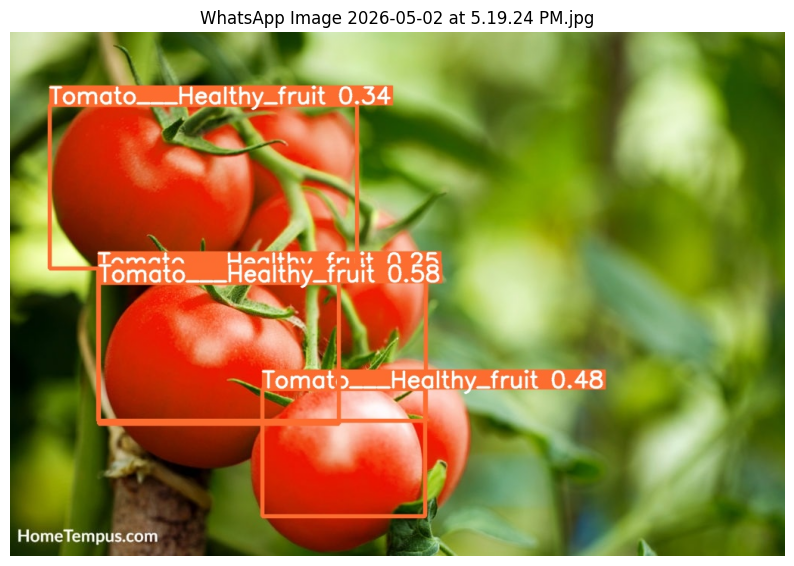

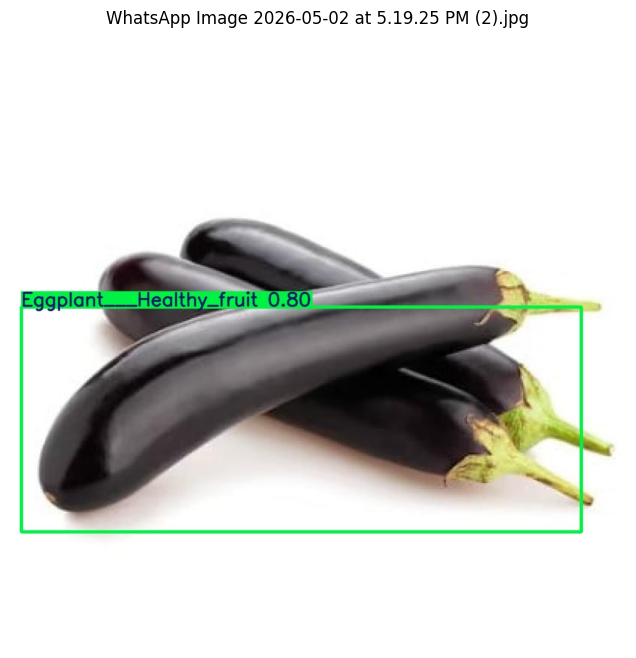

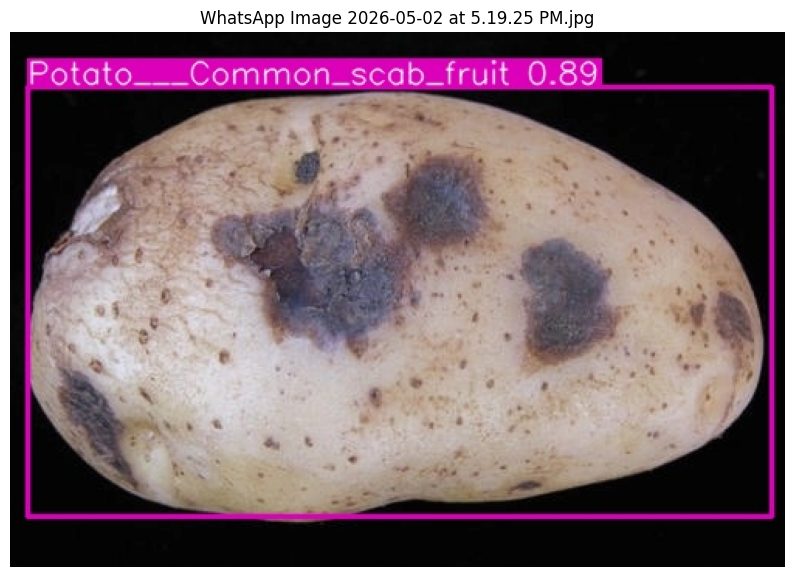

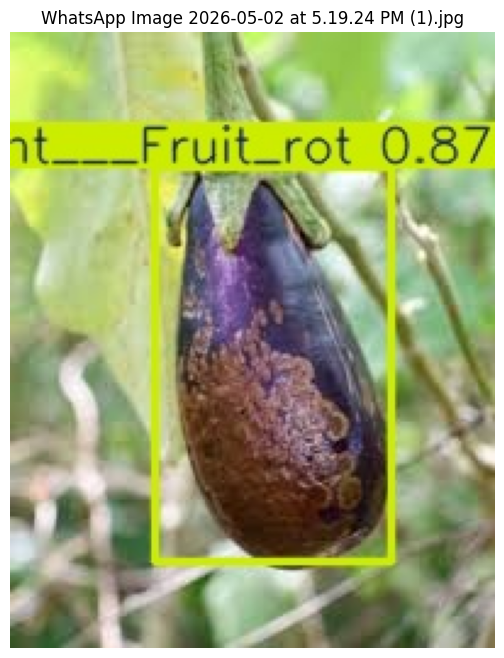

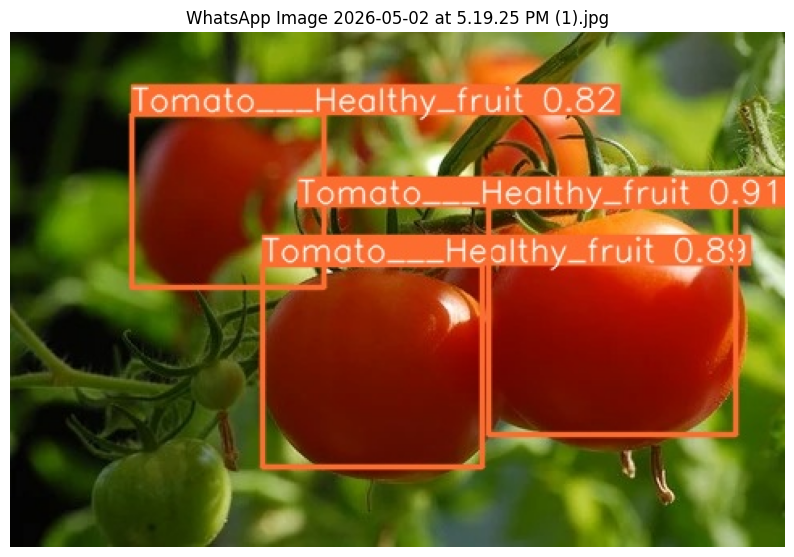

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 267.2±190.4 MB/s, size: 16.4 KB)
val: Scanning /content/dataset_final/valid/labels.cache... 960 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 960/960 287.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 7.1it/s 8.4s
                   all        960       1174      0.976      0.981      0.989      0.742
Chili___Anthracnose_fruit         36         92      0.978      0.957       0.99      0.574
Chili___Bacterial_leaf_spot         51         55      0.964      0.985      0.995      0.873
 Chili___Healthy_fruit         47         47      0.966      0.979      0.991      0.511
  Chili___Healthy_leaf         49         55      0.994          1      0.995      0.755
Chili___Mosaic_virus_leaf         52         52      0.985          1      0.995      0.722
Eggplant___Cercospora_l

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load model
model = YOLO("/content/best (5).pt")

# Predict on external test images
model.predict(
    source="/content/test_img",
    save=True,
    conf=0.25
)

# Show prediction results
predict_path = "/content/runs/detect/predict"

for img_name in os.listdir(predict_path):

    if img_name.endswith(('.jpg', '.png', '.jpeg')):

        img_path = os.path.join(predict_path, img_name)

        image = Image.open(img_path)

        plt.figure(figsize=(10,8))
        plt.imshow(image)
        plt.axis("off")
        plt.title(img_name)
        plt.show()

# Evaluation Metrics
results = model.val(data="/content/dataset_final/data.yaml")

print("\nEvaluation Metrics:\n")

print(f"Precision: {results.box.mp:.4f}")
print(f"Recall: {results.box.mr:.4f}")
print(f"mAP@0.5: {results.box.map50:.4f}")

In [ ]:
import os
print(os.path.exists("/content/best (5).pt"))

True


In [ ]:
os.path.getsize("/content/best (5).pt")

22495658

In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO("/content/best (5).pt")

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'all_images', 'drive', 'all_labels', 'best (5).pt', '.ipynb_checkpoints', 'best', 'dataset_final', 'crop-disease-1', 'sample_data']


In [ ]:
print("Saving to:", output_folder)

Saving to: /content/drive/MyDrive/project_results


# Severity Estimation Logic

In [ ]:
import os
import cv2
import pandas as pd
from ultralytics import YOLO

model = YOLO("/content/best (5).pt")

folder_path = "/content/dataset_final/test/images"

output_folder = "results"
os.makedirs(output_folder, exist_ok=True)

data = []

for img_name in os.listdir(folder_path):
    img_path = os.path.join(folder_path, img_name)

    image = cv2.imread(img_path)

    if image is None:
        continue

    h, w, _ = image.shape
    image_area = h * w

    results = model(image)
    boxes = results[0].boxes

    count = len(boxes)
    total_disease_area = 0

    if count == 0:
        level = "No Disease"
    else:
        for box in boxes:

            x1, y1, x2, y2 = box.xyxy[0]
            cls = int(box.cls[0])
            label_name = model.names[cls]

            if "Healthy" in label_name:
                continue

            box_area = (x2 - x1) * (y2 - y1)
            total_disease_area += box_area

            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
            conf = float(box.conf[0])

            label = f"{label_name} {conf:.2f}"

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        if total_disease_area == 0:
            level = "No Disease"
        else:
            severity = total_disease_area / image_area

            if severity < 0.1:
                level = "Mild"
            elif severity < 0.3:
                level = "Moderate"
            else:
                level = "Severe"

    cv2.putText(image, f"Count: {count}", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(image, f"Severity: {level}", (10, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    save_path = os.path.join(output_folder, img_name)
    cv2.imwrite(save_path, image)

    data.append([img_name, count, level])

df = pd.DataFrame(data, columns=["Image", "Count", "Severity"])

print("\nResults Table:\n")
print(df)

df.to_csv("results.csv", index=False)


0: 320x320 1 Eggplant___Colorado_potato_beetle, 10.0ms
Speed: 3.8ms preprocess, 10.0ms inference, 42.2ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 1 Eggplant___Cercospora_leaf_spot, 8.6ms
Speed: 1.3ms preprocess, 8.6ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 1 Tomato___Antrhacnose_fruit, 8.4ms
Speed: 1.0ms preprocess, 8.4ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 1 Potato___Healthy_leaf, 8.7ms
Speed: 1.0ms preprocess, 8.7ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 1 Eggplant___Healthy_fruit, 8.5ms
Speed: 1.0ms preprocess, 8.5ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 1 Tomato___Early_blight_leaf, 8.6ms
Speed: 0.8ms preprocess, 8.6ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 320)

0: 320x320 1 Eggplant___Healthy_leaf, 8.5ms
Speed: 1.0ms preprocess, 8.5ms inference, 1.2ms postprocess per image at shape (1, 

# Showing Severity Estimation and Diseases counts on some samples from the testing set

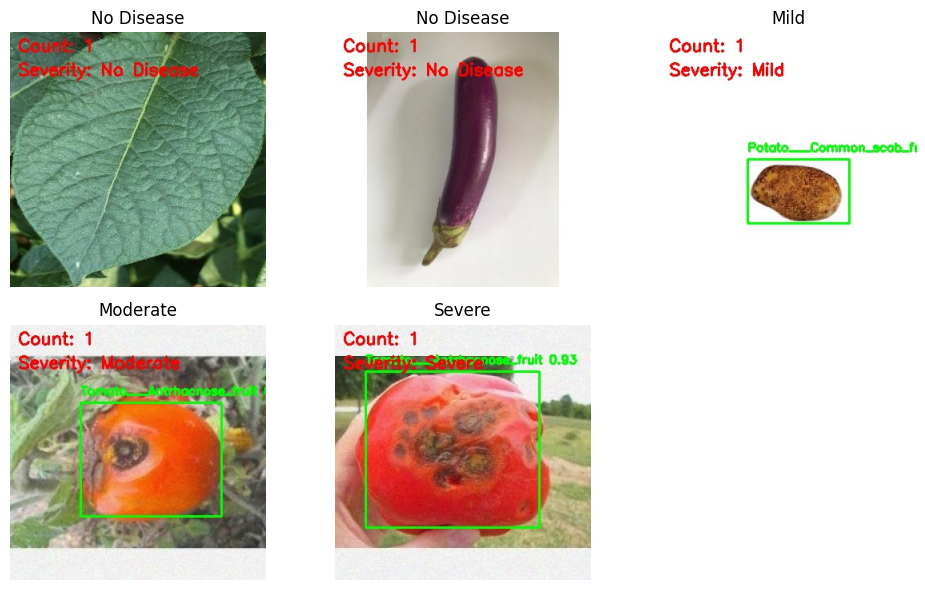

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import pandas as pd

results_folder = "results"

no_disease = df[df["Severity"] == "No Disease"].head(2)
mild = df[df["Severity"] == "Mild"].tail(1)
moderate = df[df["Severity"] == "Moderate"].tail(1)
severe = df[df["Severity"] == "Severe"].tail(1)
selected = pd.concat([no_disease, mild, moderate , severe])

plt.figure(figsize=(10, 6))

for i, (_, row) in enumerate(selected.iterrows()):
    img_name = row["Image"]
    severity = row["Severity"]

    img_path = os.path.join(results_folder, img_name)
    image = cv2.imread(img_path)

    if image is None:
        print("Error loading:", img_name)
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(severity)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Visualization

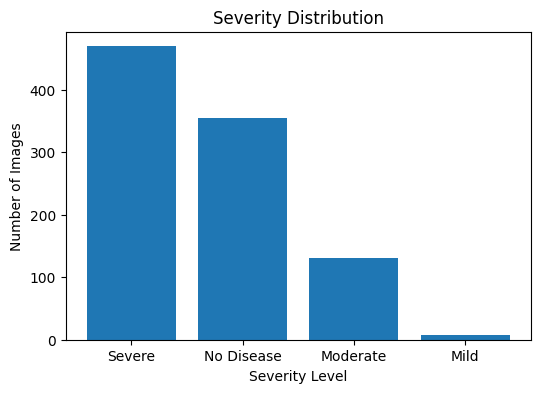

In [ ]:
import matplotlib.pyplot as plt

severity_counts = df["Severity"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(severity_counts.index, severity_counts.values)

plt.title("Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Images")

plt.show()

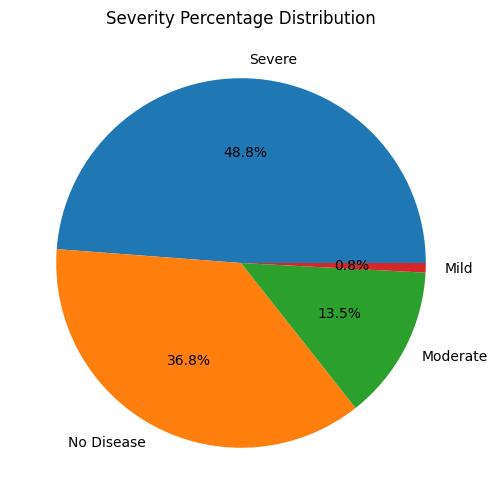

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    severity_counts.values,
    labels=severity_counts.index,
    autopct='%1.1f%%'
)

plt.title("Severity Percentage Distribution")
plt.show()

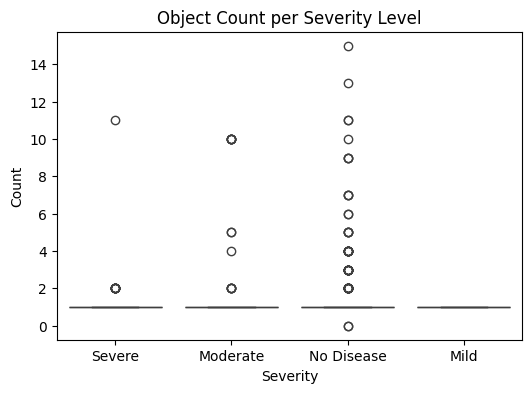

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="Severity", y="Count", data=df)

plt.title("Object Count per Severity Level")
plt.show()